Importing Required Libraries

In [2]:
#packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Used to upload files in Google Colab
from google.colab import files

Uploading Dataset Files

In [3]:
# Upload datasets from the local system into Google Colab
uploaded = files.upload()

In [ ]:
#Loading Files in Data frames
usd = pd.read_csv("DTWEXBGS.csv", sep=",")
gold = pd.read_csv("monthly.csv",sep=",")

Cleaning the Gold Price Dataset

In [ ]:
gold

,Date,Price
0,1/1/1833 0:00:00,18.93
1,2/1/1833 0:00:00,18.93
2,3/1/1833 0:00:00,18.93
3,4/1/1833 0:00:00,18.93
4,5/1/1833 0:00:00,18.93
...,...,...
2306,3/1/2025 0:00:00,"2,983.25"
2307,4/1/2025 0:00:00,"3,217.64"
2308,5/1/2025 0:00:00,"3,309.49"
2309,6/1/2025 0:00:00,"3,352.66"


In [ ]:
#chnaging , in price to space and also changing to numeric type
gold['Price'] = gold['Price'].str.replace(',', '')
gold['Price'] = pd.to_numeric(gold['Price'])

#changing date into index
gold.set_index('Date', inplace=True)

In [ ]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2311 entries, 1/1/1833 0:00:00 to 7/1/2025 0:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   2311 non-null   float64
dtypes: float64(1)
memory usage: 36.1+ KB


Cleaning the USD Exchange Rate Dataset

In [ ]:
usd

,Date,Exchange rate
0,1/2/2006 0:00:00,85.52
1,1/3/2006 0:00:00,85.60
2,1/4/2006 0:00:00,85.64
3,1/5/2006 0:00:00,85.71
4,1/6/2006 0:00:00,85.73
...,...,...
5256,2/24/2026 0:00:00,NaN
5257,2/25/2026 0:00:00,NaN
5258,2/26/2026 0:00:00,NaN
5259,2/27/2026 0:00:00,NaN


In [ ]:
# Remove rows where 'Date' column contains 'observation_date'
usd = usd[usd['Date'] != 'observation_date']
#changing to datetime
usd['Date'] = pd.to_datetime(usd['Date'])
#chnaging exchange rate into numeric formate
usd['Exchange rate'] = pd.to_numeric(usd['Exchange rate'])
#changing date into index
usd.set_index('Date', inplace=True)


/tmp/ipykernel_266/3508041155.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usd['Date'] = pd.to_datetime(usd['Date'])
/tmp/ipykernel_266/3508041155.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usd['Exchange rate'] = pd.to_numeric(usd['Exchange rate'])
/tmp/ipykernel_266/3508041155.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  usd_monthly = usd.resample('M').mean()


Converting Daily USD Data to Monthly Frequency

In [ ]:
#chnaging daily to monthly
usd_monthly = usd.resample('M').mean()
usd_monthly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 242 entries, 2006-01-31 to 2026-02-28
Freq: ME
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Exchange rate  233 non-null    float64
dtypes: float64(1)
memory usage: 3.8 KB


Aligning Date Formats Before Merging

In [ ]:
#fixing formate of datetime of both dataset before merging
gold.index = pd.to_datetime(gold.index)
gold.index = gold.index.to_period('M').to_timestamp('M')

usd_monthly.index = pd.to_datetime(usd_monthly.index)
usd_monthly.index = usd_monthly.index.to_period('M').to_timestamp('M')

Merging Gold and USD Datasets

In [ ]:
#merging both dataframe
df = pd.merge(gold, usd_monthly, left_index=True, right_index=True, how='inner')

In [ ]:
df

,Price,Exchange rate
Date,,
2006-01-31,549.86,85.871818
2006-02-28,555.00,86.262500
2006-03-31,557.09,86.459130
2006-04-30,610.65,86.570500
2006-05-31,675.39,86.731304
...,...,...
2025-03-31,2983.25,128.055238
2025-04-30,3217.64,128.552727
2025-05-31,3309.49,129.521111


Handling Missing Values

In [ ]:
#removing empty rows
df.isna().sum()

,0
Price,0
Exchange rate,2


In [ ]:
df[df.isna().any(axis=1)]

,Price,Exchange rate
Date,,
2025-06-30,3352.66,NaN
2025-07-31,3340.15,NaN


In [ ]:
df = df.dropna()

In [ ]:
#rechecking
df.isna().sum()

,0
Price,0
Exchange rate,0


In [ ]:
df.to_excel('merged dataset.xlsx')

#EDA

Calculating Log Returns

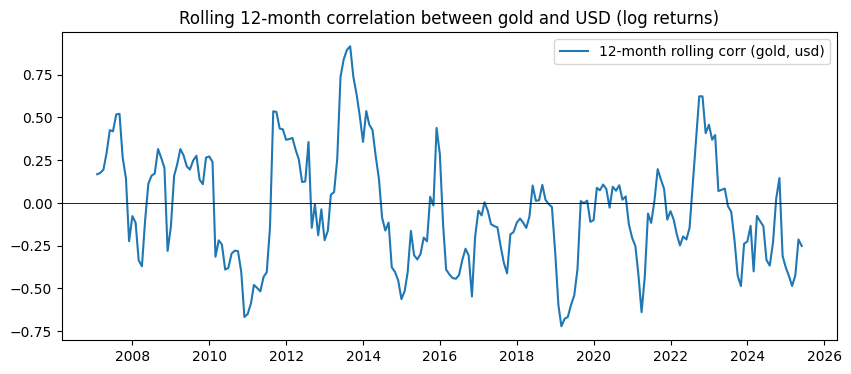

In [ ]:
# Rolling correlation (monthly data, 12-month window typical)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure correct names
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.rename(columns={c: c.strip() for c in df.columns})

# compute log returns (more stationary and common in finance)
df['gold_logret'] = np.log(df['Price']).diff()
df['usd_logret']  = np.log(df['Exchange rate']).diff()

# drop NA
df_ret = df[['gold_logret','usd_logret']].dropna()

# rolling correlation (12 months)
window = 12
rolling_corr = df_ret['gold_logret'].rolling(window).corr(df_ret['usd_logret'])

# plot
plt.figure(figsize=(10,4))
plt.plot(rolling_corr, label=f'{window}-month rolling corr (gold, usd)')
plt.axhline(0, color='k', linewidth=0.6)
plt.legend()
plt.title(f'Rolling {window}-month correlation between gold and USD (log returns)')
plt.show()

Rolling Correlation Analysis

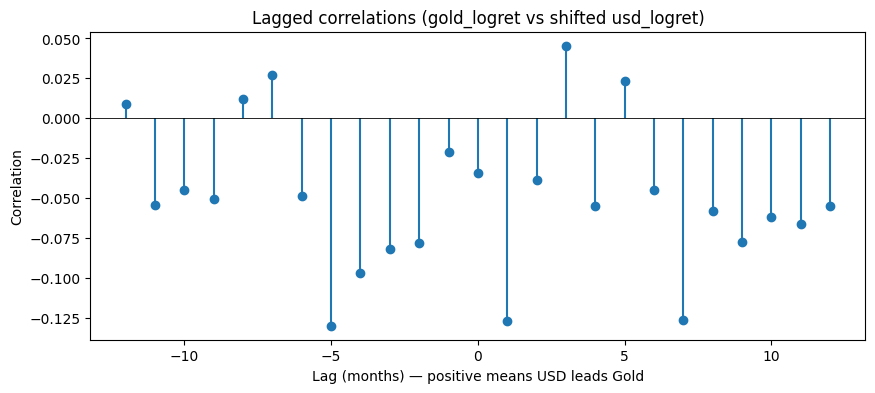

Top positive correlations (usd leads):
         corr
lag          
 3   0.045421
-7   0.026891
 5   0.023384
-8   0.012054
-12  0.008668

Top negative correlations (usd leads):
         corr
lag          
-5  -0.130040
 1  -0.127063
 7  -0.126321
-4  -0.097088
-3  -0.082111


In [ ]:
#  Lag correlation scan
max_lag = 12   # months (you can increase to 24)
lags = range(-max_lag, max_lag+1)
corrs = []

for lag in lags:
    # positive lag: usd leads gold by `lag` months (i.e., shift usd forward)
    corr = df_ret['gold_logret'].corr(df_ret['usd_logret'].shift(lag))
    corrs.append(corr)

lag_df = pd.DataFrame({'lag': list(lags), 'corr': corrs}).set_index('lag')

# plot
plt.figure(figsize=(10,4))
plt.stem(lag_df.index, lag_df['corr'], basefmt=" ")
plt.axhline(0, color='k', linewidth=0.6)
plt.xlabel('Lag (months) — positive means USD leads Gold')
plt.ylabel('Correlation')
plt.title('Lagged correlations (gold_logret vs shifted usd_logret)')
plt.show()

# show strongest lags
print("Top positive correlations (usd leads):")
print(lag_df.sort_values('corr', ascending=False).head(5))
print("\nTop negative correlations (usd leads):")
print(lag_df.sort_values('corr').head(5))

Lagged Correlation Analysis

In [ ]:
#  Regression (OLS) and Granger causality
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

# use returns dataframe
Y = df_ret['gold_logret'].dropna()
X = df_ret['usd_logret'].reindex(Y.index)

# simple contemporaneous regression: gold_ret ~ usd_ret
Xc = sm.add_constant(X)
model = sm.OLS(Y, Xc, missing='drop').fit()
print(model.summary())

# Add lags of USD to regression (e.g., 1-3 month lags)
max_lags = 3
for p in range(1, max_lags+1):
    for i in range(1, p+1):
        df_ret[f'usd_lag{i}'] = df_ret['usd_logret'].shift(i)
    Xlag = sm.add_constant(df_ret[[f'usd_lag{i}' for i in range(1,p+1)]].reindex(Y.index))
    model_lag = sm.OLS(Y, Xlag, missing='drop').fit()
    print(f"\nOLS with {p} lag(s) of usd (AIC={model_lag.aic:.2f}, R2={model_lag.rsquared:.3f}):")
    print(model_lag.summary())

# Granger causality test (on returns). Null: no causality.
# Prepare a 2-column array: [gold_ret, usd_ret]
gc_df = df_ret[['gold_logret','usd_logret']].dropna()
maxlag = 6
print("\nGranger causality tests (maxlag=6). Null: usd does NOT Granger-cause gold")
grangercausalitytests(gc_df[['gold_logret','usd_logret']], maxlag=maxlag, verbose=True)

print("\nReverse test: does gold Granger-cause usd?")
print("Null: gold does NOT Granger-cause usd")
grangercausalitytests(gc_df[['usd_logret','gold_logret']], maxlag=maxlag, verbose=True)

                            OLS Regression Results                            
Dep. Variable:            gold_logret   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.2733
Date:                Fri, 06 Mar 2026   Prob (F-statistic):              0.602
Time:                        18:27:57   Log-Likelihood:                 431.81
No. Observations:                 232   AIC:                            -859.6
Df Residuals:                     230   BIC:                            -852.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0092      0.004      2.464      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(0.0856474377287786),
    np.float64(0.7700513879063026),
    np.float64(228.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.08677437769889411),
    np.float64(0.7683186309039202),
    np.int64(1)),
   'lrtest': (np.float64(0.08675808352654713),
    np.float64(0.7683397621914276),
    np.int64(1)),
   'params_ftest': (np.float64(0.08564743772882677),
    np.float64(0.7700513879062035),
    np.float64(228.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.75617523599837),
    np.float64(0.4706478030024154),
    np.float64(225.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(1.5459582602633344),
    np.float64(0.4616357447597832),
    np.int64(2)),
   'lrtest': (np.float64(1.5407858015250895),
    np.float64(0.4628311858568379),
    np.int64(2)),
   'params_ftest': (np.float64(0.7561752359983934),
    np.float64(0.4706478030024035),
    np.float64(225.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
     

VAR Model and Causality test

In [ ]:
#VAR
from statsmodels.tsa.api import VAR

data = df_ret[['gold_logret','usd_logret']]

model = VAR(data)
results = model.fit(3)

print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 06, Mar, 2026
Time:                     18:28:09
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -20.1544
Nobs:                     229.000    HQIC:                  -20.2797
Log likelihood:           1695.85    FPE:                1.43182e-09
AIC:                     -20.3644    Det(Omega_mle):     1.34814e-09
--------------------------------------------------------------------
Results for equation gold_logret
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.008302         0.004058            2.046           0.041
L1.gold_logret         0.154955         0.065873            2.352           0.019
L1.usd_logret         -6.801510         2.523403  

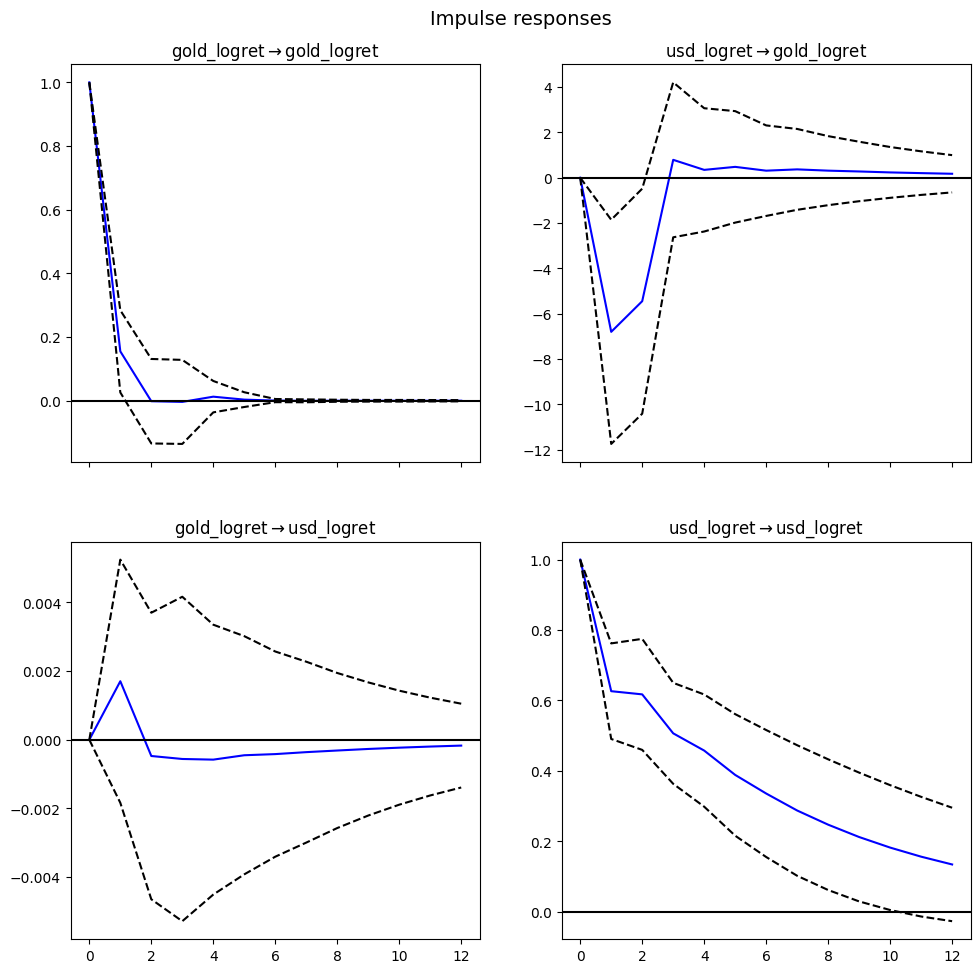

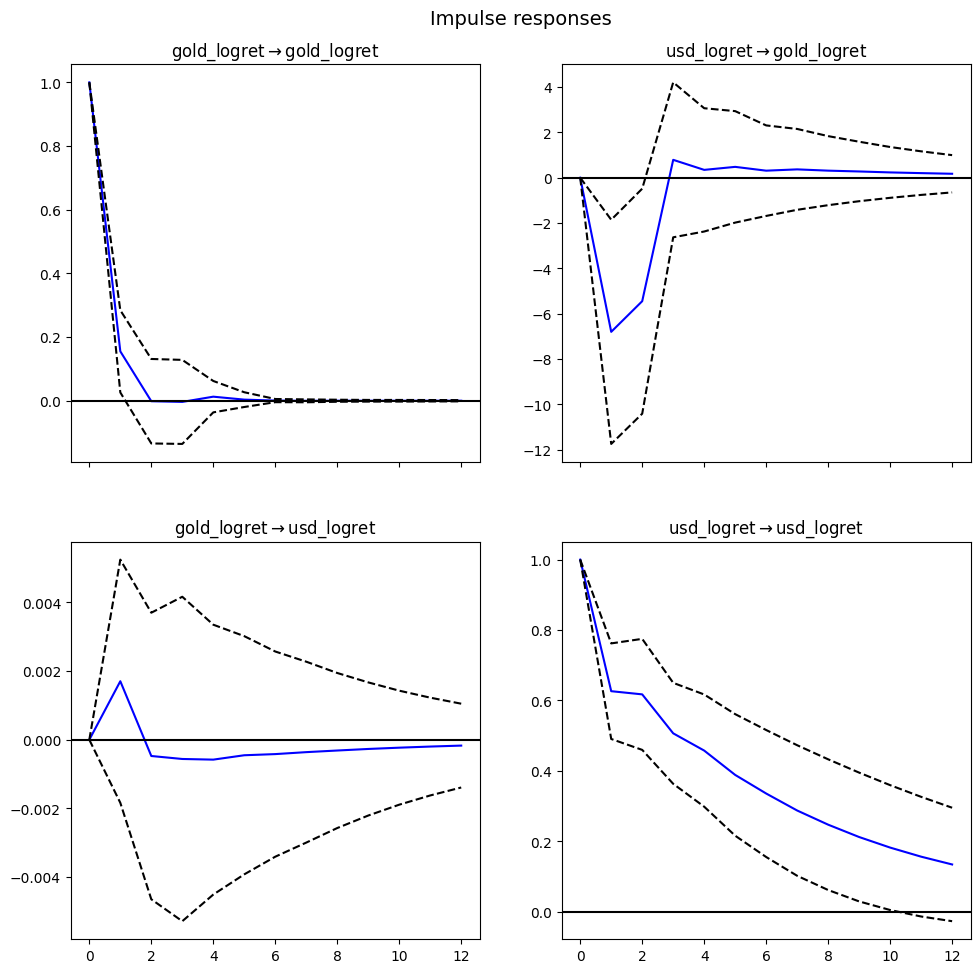

In [ ]:
#impulsive response
irf = results.irf(12)
irf.plot()

**Visualization**

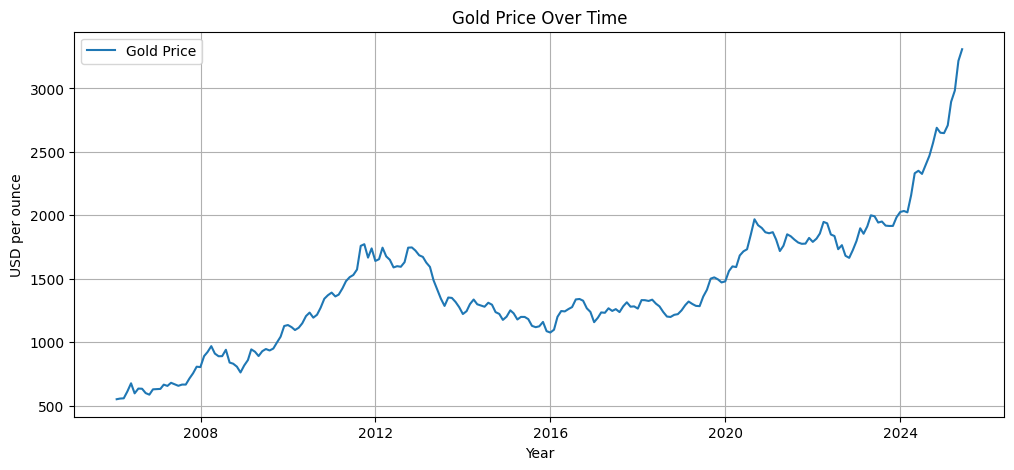

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['Price'], label='Gold Price')
plt.title("Gold Price Over Time")
plt.xlabel("Year")
plt.ylabel("USD per ounce")
plt.legend()
plt.grid(True)